In [1]:
import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F 

import matplotlib.pyplot as plt 
import seaborn as sns

## Generate Data

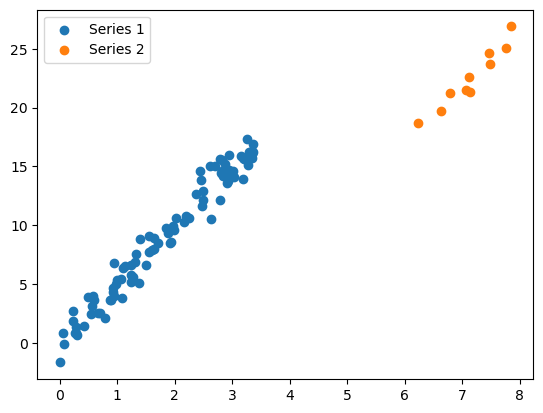

In [21]:
np.random.seed(1999)
torch.manual_seed(1999)

SIGMA = 1

# series one
M1 = 5.0
B1 = 0.0
x1 = np.random.uniform(low=0.0, high=3.4, size=90)
x1 = np.sort(x1)
y1 = M1 * x1 + B1 + np.random.normal(loc=0, scale=SIGMA, size=90)

# series two
M2 = 5.0
B2 = -13.0
x2 = np.random.uniform(low=6.0, high=8.0, size=10)
x2 = np.sort(x2)
y2 = M2 * x2 + B2 + np.random.normal(loc=0, scale=SIGMA, size=10)

plt.scatter(x1, y1, label="Series 1")
plt.scatter(x2, y2, label="Series 2")
plt.legend()

## Create the Dataset with the custom data

In [24]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, x, y):
        x = x.copy().reshape(-1,1)
        y = y.copy().reshape(-1,1)
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx, :]

x = np.concatenate((x1,x2))
y = np.concatenate((y1,y2))
train_dataset = CustomDataset(x, y)
test_dataset = CustomDataset(x, y)
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

## Code for the MLP Model

In [25]:
class MLP(nn.Module):
    def __init__(self, hidden_size=10):
        super().__init__()
        self.hidden = nn.Linear(1, hidden_size)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.hidden(x)
        x = F.relu(x)
        x = self.head(x)
        return x

    def return_mean_gradients(self):
        gradient, count = 0.0, 0.0
        for weight in [self.hidden.weight, self.hidden.bias, self.head.weight, self.head.bias]:
            gradient += np.mean(np.abs(weight.grad.detach().numpy()))
            count += weight.grad.shape[0]
        return gradient / count

## Training and Evaluation Loops

In [63]:
LR = 0.01
EPOCHS = 300

def train_step(model, data_loader, loss_fn, optimizer):
    # put the model in training mode
    model.train()
    # init the train loss
    train_loss = 0.0
    # create the grad tracking container
    gradients = 0
    # iterate over the examples
    for inputs, labels in data_loader:
        # Zero the gradients
        optimizer.zero_grad()
        # get the predictions
        preds = model(inputs)
        # get the loss
        loss = loss_fn(preds, labels)
        # update the gradients with respects to the loss
        loss.backward()
        # update the weights
        optimizer.step()
        # add the epoch loss
        train_loss += loss.item()
        # see if we are tracking the grads
        gradients += model.return_mean_gradients()
    # return the average loss which is good to know
    return train_loss / len(data_loader), gradients / len(data_loader)

def test_step(model, data_loader, loss_fn):
    # set the model to eval
    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        for inputs, labels in data_loader:
            # get the predictions
            preds = model(inputs)
            # get the loss
            loss = loss_fn(preds, labels)
            # add the epoch loss
            test_loss += loss.item()
    # return the average loss which is good to know
    return test_loss / len(data_loader)

def pred_step(model, data_loader):
    # setup the preds array
    locations = []
    predictions = []
    actuals = []
    # set the model to eval
    model.eval()
    with torch.no_grad():
        for inputs, labels in data_loader:
            # get the predictions
            preds = model(inputs)
            # add the info to the saved arrays
            locations.append(inputs.detach().numpy())
            predictions.append(preds.detach().numpy())
            actuals.append(labels.detach().numpy())
    # return the average loss which is good to know
    locations = np.concatenate(locations).flatten()
    predictions = np.concatenate(predictions).flatten()
    actuals = np.concatenate(actuals).flatten()
    return locations, predictions, actuals

def fit_model(model, train_loader, test_loader, loss_fn, optimizer, epochs=EPOCHS, verbose=True):
    gradients = []
    for epoch in range(EPOCHS):
        # train the model
        train_loss, grads = train_step(model, train_loader, loss_fn, optimizer)
        gradients.append(grads)
        # test the model
        test_loss = test_step(model, test_loader, loss_fn)
        # print the results
        if(verbose and epoch % 100 == 0):
            print(f"Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
    # test the model
    locations, predictions, actuals = pred_step(model, test_loader)
    return locations, predictions, actuals, np.mean(gradients)

def setup_model(model_class=MLP, loss_fn=nn.MSELoss, lr=LR, model_kwargs={}):
    model = model_class(**model_kwargs)
    loss_fn = loss_fn()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0, dampening=0, weight_decay=0, nesterov=False)
    return model, loss_fn, optimizer

def run_experiment(train_loader, test_loader, model_class=MLP, loss_fn=nn.MSELoss, lr=LR, verbose=True, model_kwargs={}):
    model, loss_fn, optimizer = setup_model(model_class=model_class, loss_fn=loss_fn, lr=lr, model_kwargs=model_kwargs)
    locations, preds, actuals, gradients = fit_model(model, train_loader, test_loader, loss_fn, optimizer, verbose=verbose)
    final_loss = test_step(model, test_loader, loss_fn)
    return final_loss, locations, preds, actuals, gradients

## A1 MLP on the New Data

Epoch 1, Train Loss: 187.6738, Test Loss: 96.5180
Epoch 101, Train Loss: 4.0345, Test Loss: 4.0157
Epoch 201, Train Loss: 2.0971, Test Loss: 2.0816


'Final Loss: 2.9125'

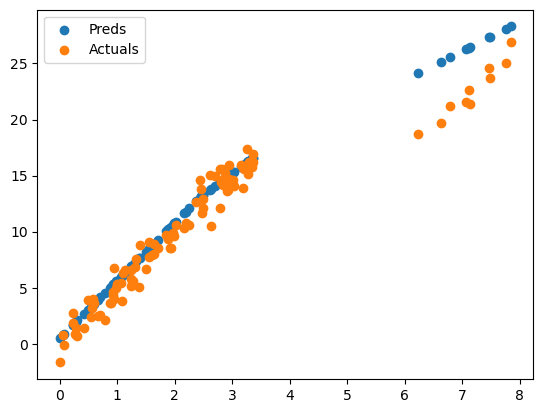

In [64]:
final_loss, locations, preds, actuals, gradients = run_experiment(train_loader, test_loader)
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")
f"Final Loss: {final_loss:.4f}"

## Create the New MLP Model

In [65]:
class NewMLP(nn.Module):
    def __init__(self, enc_size=10, dec_size=10):
        super().__init__()
        self.encoder = nn.Linear(1, enc_size)
        self.hidden = nn.Linear(enc_size, dec_size)
        self.decoder = nn.Linear(dec_size, 1)

    def forward(self, x):
        x = self.encoder(x)
        x = F.relu(x)
        x = self.hidden(x)
        x = F.relu(x)
        x = self.decoder(x)
        return x

    def return_mean_gradients(self):
        gradient, count = 0.0, 0.0
        for weight in [self.encoder.weight, self.encoder.bias, self.hidden.weight, self.hidden.bias, self.decoder.weight, self.decoder.bias]:
            gradient += np.mean(np.abs(weight.grad.detach().numpy()))
            count += weight.grad.shape[0]
        return gradient / count

## Run the Experiments with different Hyperparameter setups

We can see that having more neurons allows for a better representation, 10 by 10 seems to work well and be a good size so we will use these encoder decoder sizes for the next question.

Epoch 1, Train Loss: 132.7174, Test Loss: 124.5159
Epoch 101, Train Loss: 41.4805, Test Loss: 41.4805
Epoch 201, Train Loss: 41.4805, Test Loss: 41.4805
Encoder Size: 1, Decoder Size: 1
Final Loss: 41.4805


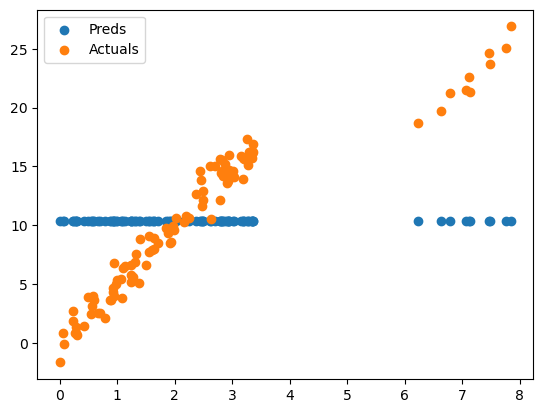

Epoch 1, Train Loss: 136.9943, Test Loss: 133.1233
Epoch 101, Train Loss: 39.9248, Test Loss: 39.7142
Epoch 201, Train Loss: 13.0849, Test Loss: 12.9805
Encoder Size: 1, Decoder Size: 2
Final Loss: 7.4512


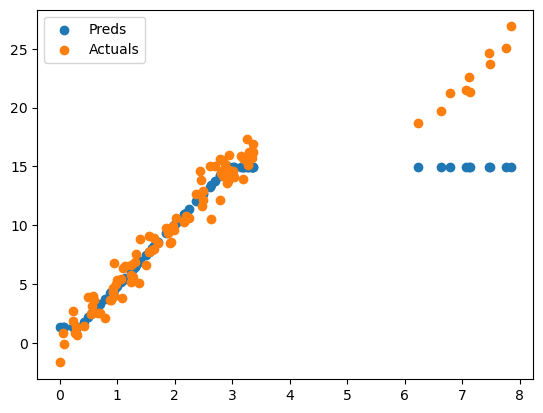

Epoch 1, Train Loss: 161.0723, Test Loss: 156.3365
Epoch 101, Train Loss: 43.5839, Test Loss: 43.5006
Epoch 201, Train Loss: 41.5175, Test Loss: 41.5160
Encoder Size: 2, Decoder Size: 1
Final Loss: 41.4811


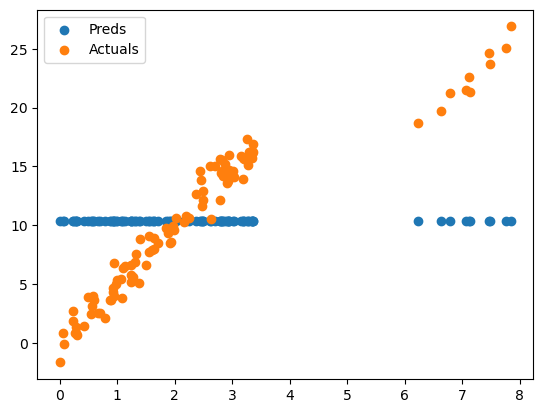

Epoch 1, Train Loss: 168.6507, Test Loss: 151.3640
Epoch 101, Train Loss: 13.3437, Test Loss: 29.4381
Epoch 201, Train Loss: 9.9390, Test Loss: 16.9379
Encoder Size: 2, Decoder Size: 2
Final Loss: 9.5010


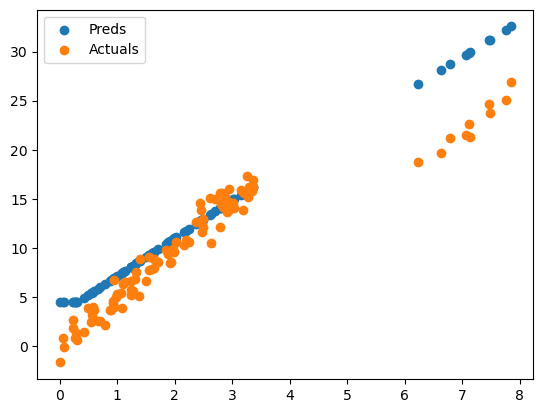

Epoch 1, Train Loss: 153.7875, Test Loss: 142.2758
Epoch 101, Train Loss: 12.8706, Test Loss: 11.4435
Epoch 201, Train Loss: 8.4627, Test Loss: 5.0967
Encoder Size: 10, Decoder Size: 10
Final Loss: 4.3275


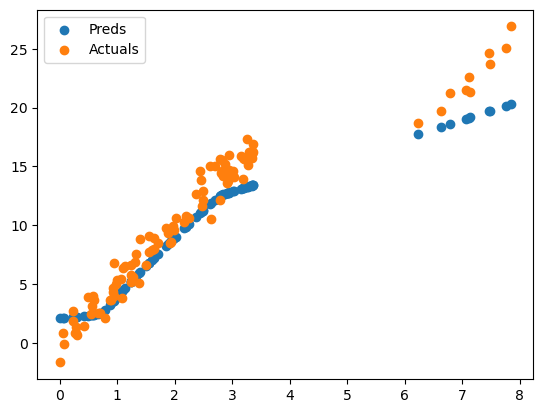

In [66]:
for enc_size, dec_size in [
    [1,1],[1,2],[2,1],[2,2],[10,10]
]:
    final_loss, locations, preds, actuals, gradients = run_experiment(train_loader, test_loader, model_class=NewMLP, loss_fn=nn.MSELoss, lr=LR, verbose=True, model_kwargs={'enc_size':enc_size, 'dec_size':dec_size})
    print("===================================================")
    print(f"Encoder Size: {enc_size}, Decoder Size: {dec_size}")
    print(f"Final Loss: {final_loss:.4f}")
    plt.scatter(locations, preds, label="Preds")
    plt.scatter(locations, actuals, label="Actuals")
    plt.legend(loc="best")
    plt.show()
    print("===================================================")

    

## Effects of Random Initialization

We can see that on the last run, even with the same setup, the random initialization played a key role in making the model suck. Now this could be helped by using a validation set and regressing until we get to a good value, but this demonstrates that random initialization can play a big role in our deep models convergence.

Epoch 1, Train Loss: 151.8844, Test Loss: 144.6079
Epoch 101, Train Loss: 20.2905, Test Loss: 7.6715
Epoch 201, Train Loss: 5.6240, Test Loss: 3.8759
Final Loss: 2.9451


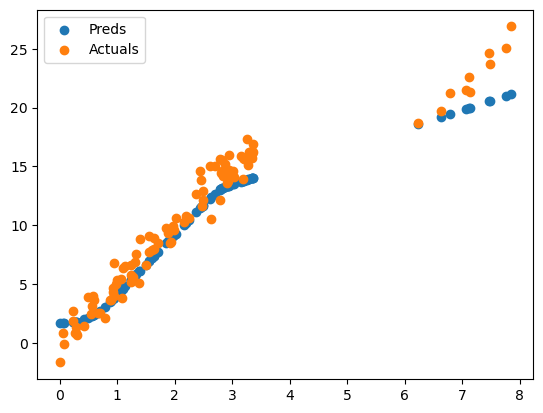

In [67]:
torch.manual_seed(2000)
final_loss, locations, preds, actuals, gradients = run_experiment(train_loader, test_loader, model_class=NewMLP, loss_fn=nn.MSELoss, lr=LR, verbose=True, model_kwargs={'enc_size':10, 'dec_size':10})
print(f"Final Loss: {final_loss:.4f}")
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")
plt.show()

Epoch 1, Train Loss: 151.1637, Test Loss: 137.5515
Epoch 101, Train Loss: 29.1792, Test Loss: 8.9040
Epoch 201, Train Loss: 9.1790, Test Loss: 5.4134
Final Loss: 3.6013


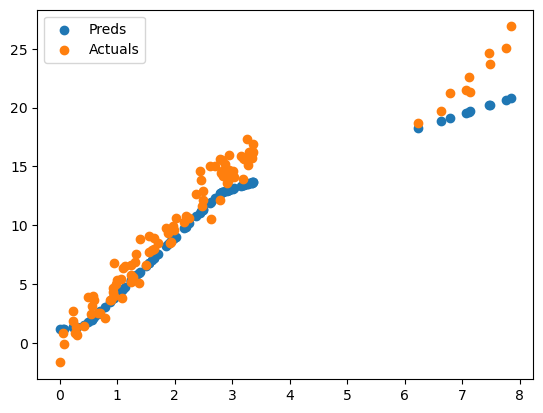

In [68]:
torch.manual_seed(123)
final_loss, locations, preds, actuals, gradients = run_experiment(train_loader, test_loader, model_class=NewMLP, loss_fn=nn.MSELoss, lr=LR, verbose=True, model_kwargs={'enc_size':10, 'dec_size':10})
print(f"Final Loss: {final_loss:.4f}")
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")
plt.show()

Epoch 1, Train Loss: 153.0350, Test Loss: 127.4041
Epoch 101, Train Loss: 13.4243, Test Loss: 13.6597
Epoch 201, Train Loss: 16.7473, Test Loss: 9.4564
Final Loss: 12.1924


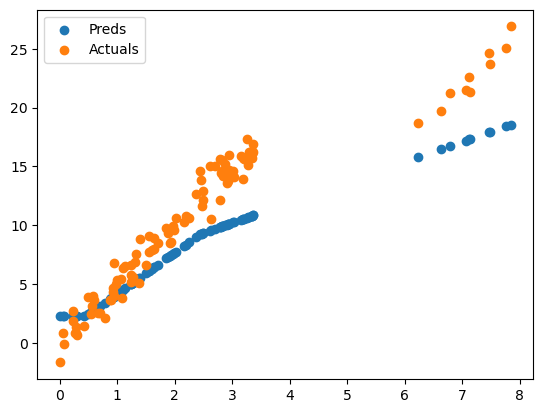

In [69]:
torch.manual_seed(897)
final_loss, locations, preds, actuals, gradients = run_experiment(train_loader, test_loader, model_class=NewMLP, loss_fn=nn.MSELoss, lr=LR, verbose=True, model_kwargs={'enc_size':10, 'dec_size':10})
print(f"Final Loss: {final_loss:.4f}")
plt.scatter(locations, preds, label="Preds")
plt.scatter(locations, actuals, label="Actuals")
plt.legend(loc="best")
plt.show()